In [1]:
#import yfinance as yf

# Specify the financial instrument and desired time period
#symbol = "AAPL"  # Example symbol for Apple Inc.
#start = "2023-04-17 09:30:00"  # Example start time (in Eastern Time)
#end = "2023-04-18 09:30:00"  # Example end time (in Eastern Time)

# Fetch hourly data from Yahoo Finance
#data = yf.download(symbol, start=start, end=end, interval="60m")

# Print the fetched data
#print(data)

In [2]:
import yfinance as yf
import numpy as np



btc = yf.Ticker('BTC-USD')

eth = yf.Ticker('ETH-USD')

btc_hist = btc.history(period='2y', interval="60m")

#eth_hist = eth.history(period='1y', interval="60m")

#btc.info

In [3]:
btc_hist 




,Open,High,Low,Close,Volume,Dividends,Stock Splits
Datetime,,,,,,,
2022-11-26 15:00:00+00:00,16564.195312,16580.892578,16514.089844,16520.373047,0,0.0,0.0
2022-11-26 16:00:00+00:00,16520.691406,16532.210938,16506.931641,16506.931641,0,0.0,0.0
2022-11-26 17:00:00+00:00,16506.666016,16523.195312,16500.863281,16520.259766,0,0.0,0.0
2022-11-26 18:00:00+00:00,16519.574219,16520.851562,16483.244141,16483.244141,0,0.0,0.0
2022-11-26 19:00:00+00:00,16481.041016,16485.601562,16450.341797,16485.601562,118161408,0.0,0.0
...,...,...,...,...,...,...,...
2024-11-26 11:00:00+00:00,92316.843750,92614.367188,91546.921875,92365.703125,3568476160,0.0,0.0
2024-11-26 12:00:00+00:00,92368.000000,92601.968750,91819.500000,92183.929688,4655177728,0.0,0.0
2024-11-26 13:00:00+00:00,92143.000000,92880.023438,91935.867188,92221.992188,1274519552,0.0,0.0


In [4]:
del btc_hist['Dividends']
del btc_hist['Stock Splits']

In [5]:
btc_hist.tail()

,Open,High,Low,Close,Volume
Datetime,,,,,
2024-11-26 11:00:00+00:00,92316.843750,92614.367188,91546.921875,92365.703125,3568476160
2024-11-26 12:00:00+00:00,92368.000000,92601.968750,91819.500000,92183.929688,4655177728
2024-11-26 13:00:00+00:00,92143.000000,92880.023438,91935.867188,92221.992188,1274519552
2024-11-26 14:00:00+00:00,92198.000000,93453.960938,91813.234375,93397.765625,1549041664
2024-11-26 15:00:00+00:00,93321.226562,93346.343750,93227.554688,93346.343750,0


In [6]:
btc_hist.head()

,Open,High,Low,Close,Volume
Datetime,,,,,
2022-11-26 15:00:00+00:00,16564.195312,16580.892578,16514.089844,16520.373047,0
2022-11-26 16:00:00+00:00,16520.691406,16532.210938,16506.931641,16506.931641,0
2022-11-26 17:00:00+00:00,16506.666016,16523.195312,16500.863281,16520.259766,0
2022-11-26 18:00:00+00:00,16519.574219,16520.851562,16483.244141,16483.244141,0
2022-11-26 19:00:00+00:00,16481.041016,16485.601562,16450.341797,16485.601562,118161408


In [7]:
btc_hist.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 17461 entries, 2022-11-26 15:00:00+00:00 to 2024-11-26 15:00:00+00:00
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Open    17461 non-null  float64
 1   High    17461 non-null  float64
 2   Low     17461 non-null  float64
 3   Close   17461 non-null  float64
 4   Volume  17461 non-null  int64  
dtypes: float64(4), int64(1)
memory usage: 818.5 KB


In [8]:
#tickers = ['BTC-USD', 'ETH-USD']

In [9]:
#import matplotlib.pyplot as plt
#for i,ticker in enumerate(tickers):
 # current_ticker = yf.Ticker(ticker)
 # plt.subplot(len(tickers),1,i+1)
 # current_ticker.history(period='1y', interval = '60m')['Close'].plot(figsize=   (8,12), title='1 year price history for ticker: '+ticker)

In [10]:
dataset = btc_hist

Machine learning

Train

In [11]:
yf.pdr_override()
from datetime import datetime

yfinance: pandas_datareader support is deprecated & semi-broken so will be removed in a future verison. Just use yfinance.


In [12]:
dataset['log_price'] = np.log(dataset['Close'])

dataset['pct_change'] = dataset['log_price'].diff()

In [13]:
dataset['stdev'] = dataset['pct_change'].rolling(window=21, center=False).std()
dataset['Volatility_BTC'] = dataset['stdev'] * (252**0.5) # Annualize.


dataset = dataset.dropna()

vol = dataset["Volatility_BTC"] * 100

In [14]:
dataset.head()

,Open,High,Low,Close,Volume,log_price,pct_change,stdev,Volatility_BTC
Datetime,,,,,,,,,
2022-11-27 12:00:00+00:00,16551.134766,16576.353516,16548.060547,16562.093750,67940352,9.714872,0.000770,0.001643,0.026085
2022-11-27 13:00:00+00:00,16559.712891,16561.314453,16538.074219,16543.888672,94322688,9.713772,-0.001100,0.001653,0.026233
2022-11-27 14:00:00+00:00,16544.333984,16557.345703,16532.949219,16537.335938,0,9.713376,-0.000396,0.001648,0.026159
2022-11-27 15:00:00+00:00,16540.505859,16578.734375,16532.582031,16577.201172,0,9.715784,0.002408,0.001637,0.025984
2022-11-27 16:00:00+00:00,16576.861328,16576.861328,16547.488281,16547.488281,231663616,9.713990,-0.001794,0.001698,0.026953


In [15]:
dataset.shape

(17440, 9)

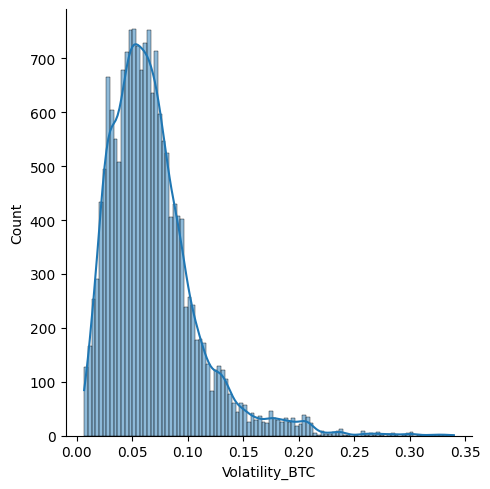

In [16]:
import seaborn as sns
sns.displot(dataset.Volatility_BTC, kde=True)

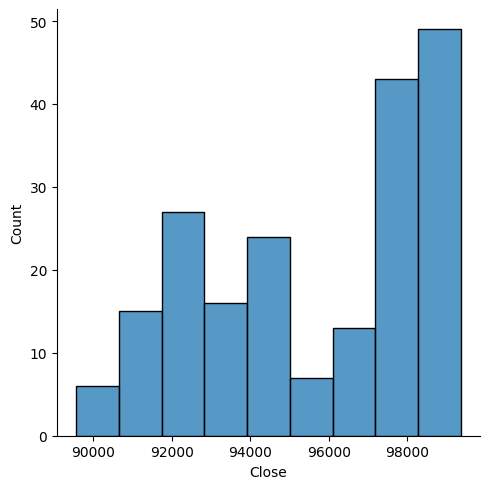

In [17]:
sns.displot(dataset['Close'].iloc[-200:])


In [18]:
dataset = dataset.dropna()

In [19]:
vol = dataset["Volatility_BTC"] *100
real_vol = dataset['Volatility_BTC']
print(real_vol)

Datetime
2022-11-27 12:00:00+00:00    0.026085
2022-11-27 13:00:00+00:00    0.026233
2022-11-27 14:00:00+00:00    0.026159
2022-11-27 15:00:00+00:00    0.025984
2022-11-27 16:00:00+00:00    0.026953
                               ...   
2024-11-26 11:00:00+00:00    0.106577
2024-11-26 12:00:00+00:00    0.105634
2024-11-26 13:00:00+00:00    0.105964
2024-11-26 14:00:00+00:00    0.115316
2024-11-26 15:00:00+00:00    0.115166
Name: Volatility_BTC, Length: 17440, dtype: float64


In [20]:
dataset.tail()


,Open,High,Low,Close,Volume,log_price,pct_change,stdev,Volatility_BTC
Datetime,,,,,,,,,
2024-11-26 11:00:00+00:00,92316.843750,92614.367188,91546.921875,92365.703125,3568476160,11.433511,-0.000771,0.006714,0.106577
2024-11-26 12:00:00+00:00,92368.000000,92601.968750,91819.500000,92183.929688,4655177728,11.431541,-0.001970,0.006654,0.105634
2024-11-26 13:00:00+00:00,92143.000000,92880.023438,91935.867188,92221.992188,1274519552,11.431954,0.000413,0.006675,0.105964
2024-11-26 14:00:00+00:00,92198.000000,93453.960938,91813.234375,93397.765625,1549041664,11.444623,0.012669,0.007264,0.115316
2024-11-26 15:00:00+00:00,93321.226562,93346.343750,93227.554688,93346.343750,0,11.444072,-0.000551,0.007255,0.115166


In [21]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 17440 entries, 2022-11-27 12:00:00+00:00 to 2024-11-26 15:00:00+00:00
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Open            17440 non-null  float64
 1   High            17440 non-null  float64
 2   Low             17440 non-null  float64
 3   Close           17440 non-null  float64
 4   Volume          17440 non-null  int64  
 5   log_price       17440 non-null  float64
 6   pct_change      17440 non-null  float64
 7   stdev           17440 non-null  float64
 8   Volatility_BTC  17440 non-null  float64
dtypes: float64(8), int64(1)
memory usage: 1.3 MB


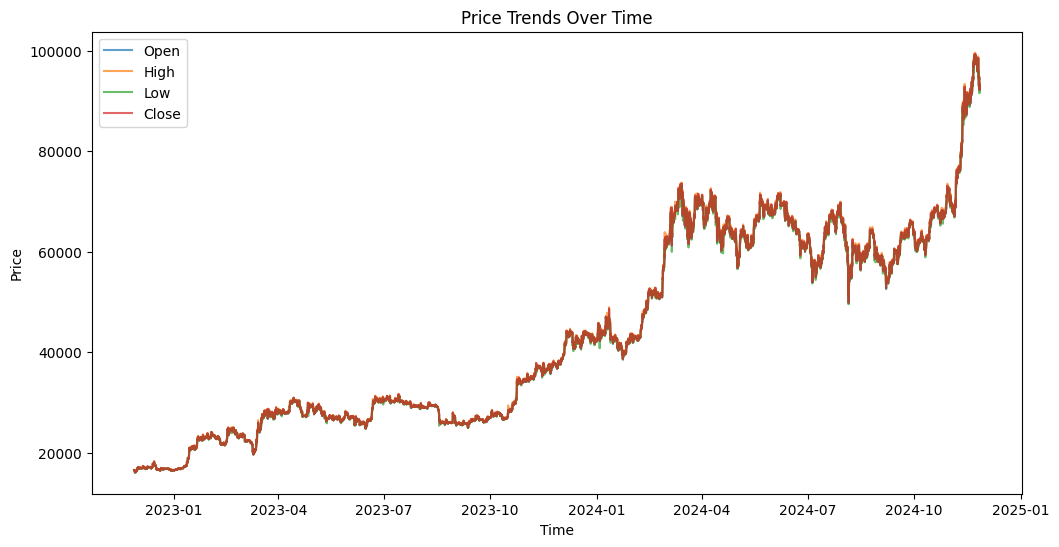

In [22]:
import matplotlib.pyplot as plt

# Plot Open, High, Low, Close prices
plt.figure(figsize=(12, 6))
plt.plot(dataset.index, dataset['Open'], label='Open', alpha=0.7)
plt.plot(dataset.index, dataset['High'], label='High', alpha=0.7)
plt.plot(dataset.index, dataset['Low'], label='Low', alpha=0.7)
plt.plot(dataset.index, dataset['Close'], label='Close', alpha=0.7)
plt.xlabel('Time')
plt.ylabel('Price')
plt.title('Price Trends Over Time')
plt.legend()
plt.show()


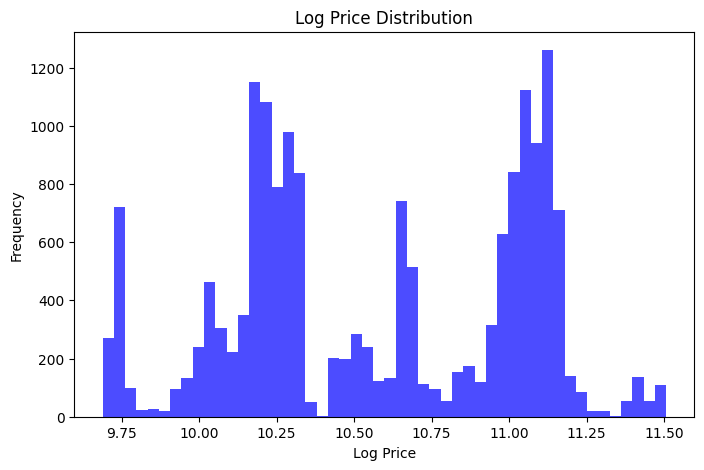

In [23]:
# Histogram of log prices
plt.figure(figsize=(8, 5))
plt.hist(dataset['log_price'], bins=50, color='blue', alpha=0.7)
plt.xlabel('Log Price')
plt.ylabel('Frequency')
plt.title('Log Price Distribution')
plt.show()


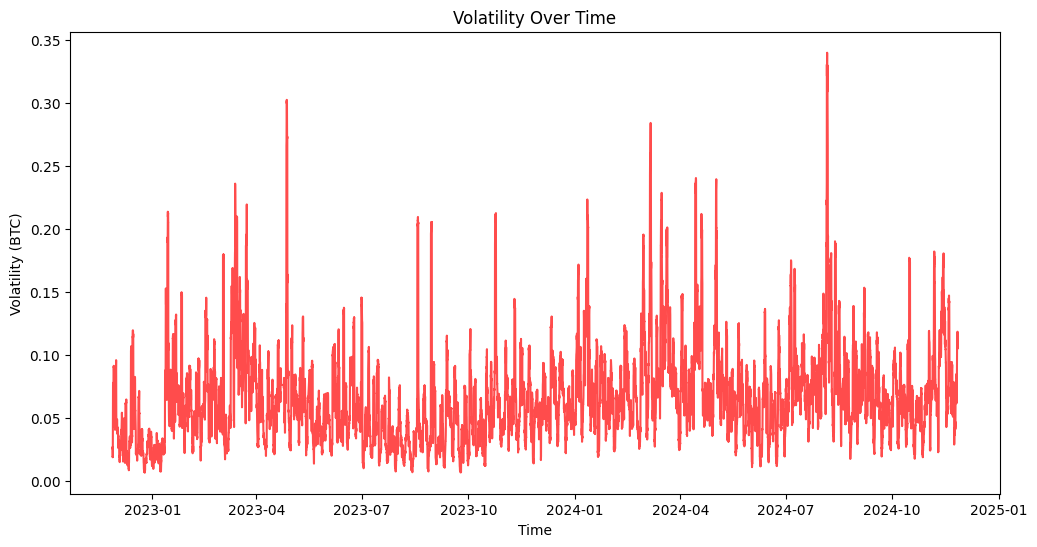

In [24]:
# Plot volatility over time
plt.figure(figsize=(12, 6))
plt.plot(dataset.index, dataset['Volatility_BTC'], color='red', alpha=0.7)
plt.xlabel('Time')
plt.ylabel('Volatility (BTC)')
plt.title('Volatility Over Time')
plt.show()


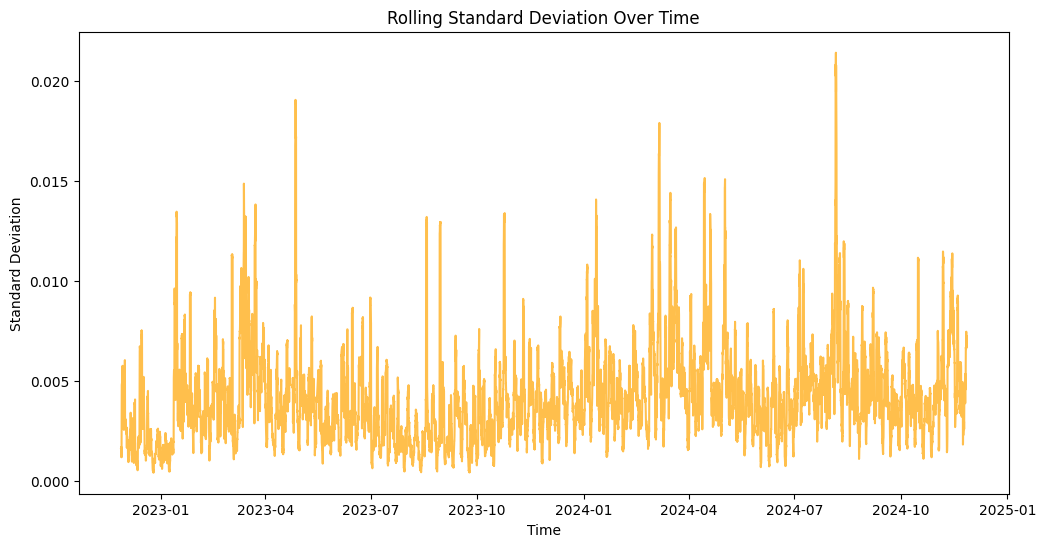

In [25]:
# Rolling standard deviation
plt.figure(figsize=(12, 6))
plt.plot(dataset.index, dataset['stdev'], color='orange', alpha=0.7)
plt.xlabel('Time')
plt.ylabel('Standard Deviation')
plt.title('Rolling Standard Deviation Over Time')
plt.show()


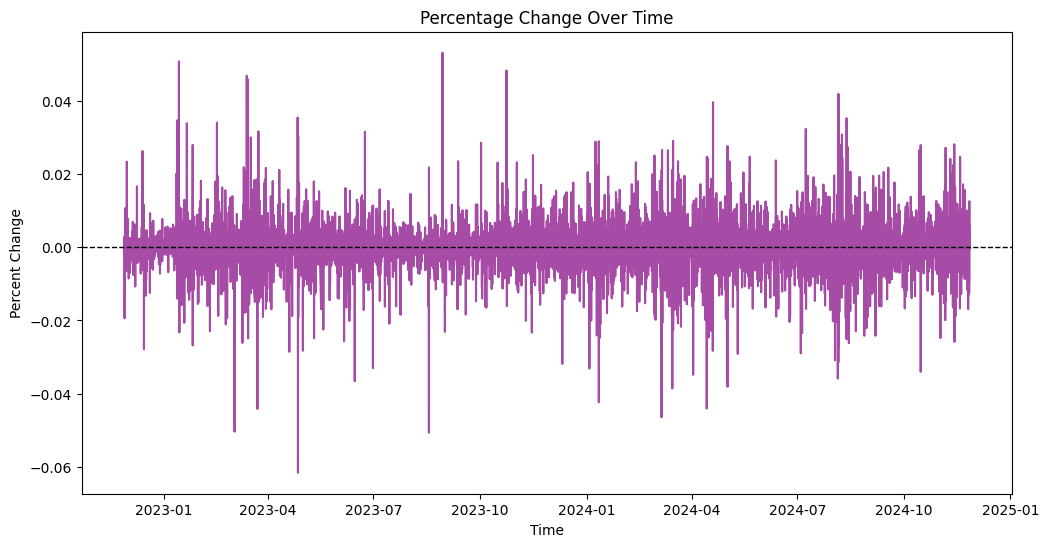

In [26]:
# Daily percentage change
plt.figure(figsize=(12, 6))
plt.plot(dataset.index, dataset['pct_change'], color='purple', alpha=0.7)
plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.xlabel('Time')
plt.ylabel('Percent Change')
plt.title('Percentage Change Over Time')
plt.show()
